In [6]:
from tensorflow.keras.layers import Input, Lambda, Dense, Flatten, GlobalAveragePooling2D
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
from glob import glob
import matplotlib.pyplot as plt
import tensorflow as tf

# Configure GPU memory growth to prevent OOM errors
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"[OK] GPU memory growth enabled for {len(gpus)} GPU(s)")
    except RuntimeError as e:
        print(e)


[OK] GPU memory growth enabled for 1 GPU(s)


In [7]:
# data loading by using keras with automatic train/validation split
# Reduced batch_size to 16 to prevent GPU memory issues
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

training_set = train_datagen.flow_from_directory(
    'removed background',
    target_size=(224, 224),
    batch_size=16,  # Reduced from 32 to prevent OOM
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=42
)


Found 4215 images belonging to 20 classes.


In [8]:
validation_set = train_datagen.flow_from_directory(
    'removed background',
    target_size=(224, 224),
    batch_size=16,  # Reduced from 32 to prevent OOM
    class_mode='categorical',
    subset='validation',
    shuffle=True,
    seed=42
)


Found 1046 images belonging to 20 classes.


In [9]:
# Load the base model
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))


In [10]:
# Freeze all the dense layers
for layer in base_model.layers:
    layer.trainable = False


In [11]:
# Define the model
from tensorflow.keras.layers import Dropout , GlobalAveragePooling2D
model = Sequential([
    base_model,
    GlobalAveragePooling2D(), # flatten()
    Dense(1024, activation='relu'),
    Dropout(0.5),
    Dense(20, activation='softmax')
])


In [12]:
model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 resnet50 (Functional)       (None, 7, 7, 2048)        23587712  
                                                                 
 global_average_pooling2d (G  (None, 2048)             0         
 lobalAveragePooling2D)                                          
                                                                 
 dense (Dense)               (None, 1024)              2098176   
                                                                 
 dropout (Dropout)           (None, 1024)              0         
                                                                 
 dense_1 (Dense)             (None, 20)                20500     
                                                                 
Total params: 25,706,388
Trainable params: 2,118,676
Non-trainable params: 23,587,712
____________________________________

In [13]:
# Compile the model
from tensorflow.keras.optimizers import Adam
# model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.compile(optimizer=Adam(learning_rate=1e-5), loss='categorical_crossentropy', metrics=['accuracy'])


In [14]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from pathlib import Path

# Create callbacks list
callback = [
    EarlyStopping(
        monitor="val_accuracy",
        min_delta=0.00001,
        patience=45,
        verbose=1,
        mode="auto",
        baseline=None,
        restore_best_weights=True # false
    ),
    ModelCheckpoint(
        filepath="ResNet50_best_model.keras",
        monitor="val_accuracy",
        verbose=1,
        save_best_only=True,
        mode="max",  # Changed to "max" because higher accuracy is better
        save_weights_only=False
    )
]


In [15]:
# Fit the model
training_model=model.fit(training_set, epochs=150, validation_data=validation_set , callbacks=callback)


Epoch 1/150
264/264 [==============================] - ETA: 0s - loss: 3.3250 - accuracy: 0.0482
Epoch 1: val_accuracy improved from -inf to 0.05163, saving model to ResNet50_best_model.keras
264/264 [==============================] - 140s 514ms/step - loss: 3.3250 - accuracy: 0.0482 - val_loss: 2.9735 - val_accuracy: 0.0516
Epoch 2/150
264/264 [==============================] - ETA: 0s - loss: 3.2008 - accuracy: 0.0529
Epoch 2: val_accuracy improved from 0.05163 to 0.08891, saving model to ResNet50_best_model.keras
264/264 [==============================] - 129s 489ms/step - loss: 3.2008 - accuracy: 0.0529 - val_loss: 2.9596 - val_accuracy: 0.0889
Epoch 3/150
264/264 [==============================] - ETA: 0s - loss: 3.1553 - accuracy: 0.0595
Epoch 3: val_accuracy did not improve from 0.08891
264/264 [==============================] - 128s 486ms/step - loss: 3.1553 - accuracy: 0.0595 - val_loss: 2.9528 - val_accuracy: 0.0813
Epoch 4/150
264/264 [==============================] - ETA: 

In [16]:
# model evaluation on training set
training_set.reset()
training_loss , train_accuracy = model.evaluate(training_set)


264/264 [==============================] - 96s 365ms/step - loss: 2.4789 - accuracy: 0.2565


In [17]:
# model evaluation on validation set
validation_set.reset()
validation_loss , validation_accuracy = model.evaluate(validation_set)


66/66 [==============================] - 26s 387ms/step - loss: 2.5859 - accuracy: 0.2122


In [18]:
tf.keras.callbacks.History()


In [19]:
training_model.history


{'loss': [3.324993848800659,
  3.2008397579193115,
  3.155271053314209,
  3.137373685836792,
  3.1041762828826904,
  3.06533145904541,
  3.0501742362976074,
  3.0166006088256836,
  3.017557144165039,
  2.9859352111816406,
  2.9858479499816895,
  2.963945150375366,
  2.963679313659668,
  2.9384002685546875,
  2.940326690673828,
  2.9240341186523438,
  2.91245174407959,
  2.8978514671325684,
  2.9053664207458496,
  2.8916358947753906,
  2.8841066360473633,
  2.8743481636047363,
  2.873851776123047,
  2.865629196166992,
  2.860873222351074,
  2.8536016941070557,
  2.8506579399108887,
  2.8426997661590576,
  2.8472702503204346,
  2.838146448135376,
  2.832909345626831,
  2.8285651206970215,
  2.8258628845214844,
  2.8133938312530518,
  2.8119945526123047,
  2.8069207668304443,
  2.8065345287323,
  2.8020269870758057,
  2.7994368076324463,
  2.7928385734558105,
  2.785806179046631,
  2.7845821380615234,
  2.78139066696167,
  2.771857738494873,
  2.7748944759368896,
  2.7632546424865723,
  2

In [20]:
# record the history in json format

import json
with open("training_hist_ResNet50_version_2.json" , "w") as f:
    json.dump(training_model.history , f)


In [21]:
# viz
# Create epochs list based on actual number of epochs trained (not fixed 150)
epochs = list(range(1, len(training_model.history['accuracy']) + 1))
epochs


[1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 12,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 21,
 22,
 23,
 24,
 25,
 26,
 27,
 28,
 29,
 30,
 31,
 32,
 33,
 34,
 35,
 36,
 37,
 38,
 39,
 40,
 41,
 42,
 43,
 44,
 45,
 46,
 47,
 48,
 49,
 50,
 51,
 52,
 53,
 54,
 55,
 56,
 57,
 58,
 59,
 60,
 61,
 62,
 63,
 64,
 65,
 66,
 67,
 68,
 69,
 70,
 71,
 72,
 73,
 74,
 75,
 76,
 77,
 78,
 79,
 80,
 81,
 82,
 83,
 84,
 85,
 86,
 87,
 88,
 89,
 90,
 91,
 92,
 93,
 94,
 95,
 96,
 97,
 98,
 99,
 100,
 101,
 102,
 103,
 104,
 105,
 106,
 107,
 108,
 109,
 110,
 111,
 112,
 113,
 114,
 115,
 116,
 117,
 118,
 119,
 120,
 121,
 122,
 123,
 124,
 125,
 126,
 127,
 128,
 129,
 130,
 131,
 132,
 133,
 134,
 135,
 136,
 137,
 138,
 139,
 140,
 141,
 142,
 143,
 144,
 145,
 146,
 147,
 148,
 149,
 150]

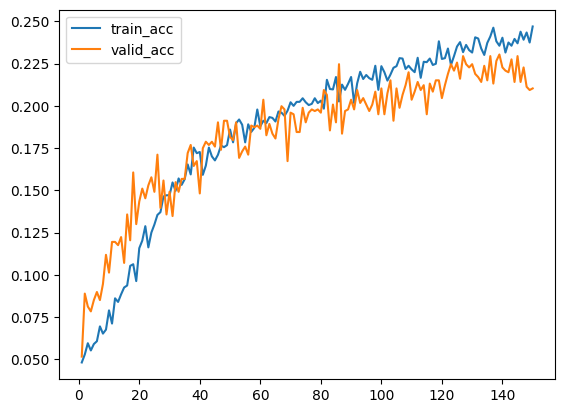

In [22]:
plt.plot(epochs,training_model.history['accuracy'] , label = 'train_acc')
plt.plot(epochs,training_model.history['val_accuracy'] , label='valid_acc')
plt.legend()
plt.show()


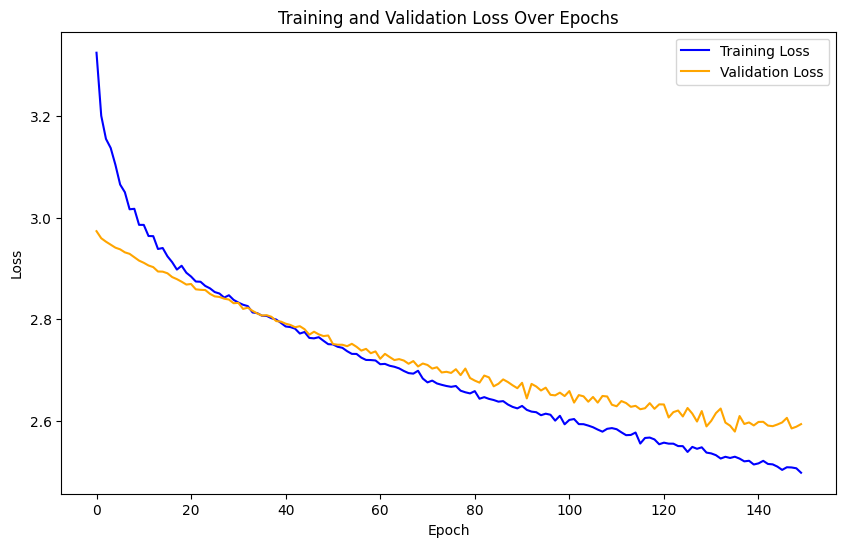

In [23]:
import json
import matplotlib.pyplot as plt

# Load the JSON data from the file
with open("training_hist_ResNet50_version_2.json") as f:
    data = json.load(f)

# Extract loss and validation loss
loss = data['loss']
val_loss = data['val_loss']

# Plot the training and validation loss
plt.figure(figsize=(10, 6))
plt.plot(loss, label='Training Loss', color='blue')
plt.plot(val_loss, label='Validation Loss', color='orange')

# Add titles and labels
plt.title('Training and Validation Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Show the plot
plt.show()


In [24]:
class_name = list(training_set.class_indices.keys())
class_name


['Aloevera',
 'Amla',
 'Bamboo',
 'Bhrami',
 'Bringaraja',
 'Castor',
 'Coffee',
 'Coriender',
 'Curry',
 'Eucalyptus',
 'Ginger',
 'Guava',
 'Henna',
 'Hibiscus',
 'Lemon',
 'Mint',
 'Neem',
 'Onion',
 'Palak(Spinach)',
 'Papaya']

In [25]:
# Create test set for evaluation (without augmentation)
test_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

test_set = test_datagen.flow_from_directory(
    'removed background',
    target_size=(224, 224),
    batch_size=16,  # Reduced from 32 to prevent OOM
    class_mode='categorical',
    subset='validation',
    shuffle=False,# one by one check all the directory
    seed=42
)


Found 1046 images belonging to 20 classes.


In [26]:
y_pred = model.predict(test_set)
y_pred


66/66 [==============================] - 21s 319ms/step


array([[0.22150344, 0.00592047, 0.39711958, ..., 0.01858295, 0.00828439,
        0.01754561],
       [0.0676576 , 0.00106262, 0.4871637 , ..., 0.04390412, 0.00201447,
        0.03600241],
       [0.06222177, 0.00073702, 0.42915866, ..., 0.09937844, 0.00102279,
        0.0238941 ],
       ...,
       [0.01676532, 0.01645757, 0.0129726 , ..., 0.00124202, 0.05924093,
        0.2027401 ],
       [0.02191527, 0.01976517, 0.01774578, ..., 0.0019817 , 0.06170106,
        0.17605501],
       [0.01297452, 0.01301897, 0.01149002, ..., 0.00083511, 0.05345813,
        0.26695862]], dtype=float32)

In [27]:
predicted_categories= tf.argmax(y_pred,axis=1)


In [ ]:
# Reset test_set before reading labels (it was already used for predictions)
test_set.reset()
true_categories = tf.concat([y for x,y in test_set] , axis=0)
true_categories #one hot encoding


In [ ]:
y_true= tf.argmax(true_categories,axis=1)
y_true


In [ ]:
from sklearn.metrics import classification_report , confusion_matrix
print(classification_report(y_true,predicted_categories ,target_names = class_name))


In [ ]:
cm = confusion_matrix(y_true , predicted_categories)
cm.shape


In [ ]:
import seaborn as sns
plt.figure(figsize = (12,6))
sns.heatmap(cm,linewidth=0.5, cmap='summer')
plt.xlabel('predicted class')
plt.ylabel('actual class')
plt.show()


In [ ]:
import seaborn as sns
plt.figure(figsize = (12,6))
sns.heatmap(cm,linewidth=0.5, cmap='summer' ,annot=True)
plt.xlabel('predicted class')
plt.ylabel('actual class')
plt.show()
